# 05 — Risk Classifier: XGBoost on Clause-Presence Features

This notebook builds the **risk-scoring layer** on top of the clause extraction pipeline.

### How it fits into LeaseIQ
```
Contract text  →  LegalBERT (clause extraction)  →  clause presence matrix
                                                         ↓
                                               XGBoost risk classifier
                                                         ↓
                                            Risk tier: LOW / MEDIUM / HIGH
                                                         ↓
                                              SHAP explanation of risk drivers
```

### Features used
Each contract is represented as a **41-dimensional binary vector** — one dimension
per CUAD clause category — where `1 = clause present`, `0 = clause absent`.

In this notebook we use the **ground-truth** `is_answerable` values from
`cuad_final.csv` as the feature source. In production these would be the
LegalBERT model's predictions.

### Risk label heuristic
We define risk tiers based on which *critical* clauses are missing:
- **HIGH (2)**: ≥ 3 high-risk clauses absent
- **MEDIUM (1)**: 1–2 high-risk clauses absent
- **LOW (0)**: all high-risk clauses present


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
print("Imports OK.")


Imports OK.


/Users/mustafayunus/Desktop/leaseiq-ml/leaseiq-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Build Contract-Level Feature Matrix

In [2]:
DATA_PATH = Path("../data/processed/cuad_final.csv")
df        = pd.read_csv(DATA_PATH)

# Pivot to contract x category matrix (binary: clause present / absent)
# Using max() because some (contract, category) pairs appear in both splits
feature_df = (
    df.groupby(["contract_id", "category"])["is_answerable"]
    .max()
    .astype(int)
    .unstack(fill_value=0)
    .reset_index()
    .rename_axis(None, axis=1)
)

# Preserve the train/test split label for each contract
split_map       = df.drop_duplicates("contract_id").set_index("contract_id")["split"]
feature_df["split"] = feature_df["contract_id"].map(split_map)

print(f"Feature matrix shape: {feature_df.shape}")
print(f"  Contracts: {len(feature_df)}")
print(f"  Features : {feature_df.shape[1] - 2}  (clause categories)")
feature_df.head(3)


Feature matrix shape: (510, 43)
  Contracts: 510
  Features : 41  (clause categories)


,contract_id,Affiliate License-Licensee,Affiliate License-Licensor,Agreement Date,Anti-Assignment,Audit Rights,Cap On Liability,Change Of Control,Competitive Restriction Exception,Covenant Not To Sue,...,Revenue/Profit Sharing,Rofr/Rofo/Rofn,Source Code Escrow,Termination For Convenience,Third Party Beneficiary,Uncapped Liability,Unlimited/All-You-Can-Eat-License,Volume Restriction,Warranty Duration,split
0,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,0,0,1,1,1,1,1,0,0,...,1,0,0,0,0,1,0,0,0,train
1,ABILITYINC_06_15_2020-EX-4.25-SERVICES AGREEMENT,0,0,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,train
2,ACCELERATEDTECHNOLOGIESHOLDINGCORP_04_24_2003-...,0,0,0,1,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,test


In [3]:
# List all clause-type feature columns (exclude metadata)
FEATURE_COLS = [c for c in feature_df.columns
                if c not in {"contract_id", "split"}]

print(f"Feature columns ({len(FEATURE_COLS)} total):")
for i, col in enumerate(sorted(FEATURE_COLS), 1):
    print(f"  {i:>2}. {col}")


Feature columns (41 total):
   1. Affiliate License-Licensee
   2. Affiliate License-Licensor
   3. Agreement Date
   4. Anti-Assignment
   5. Audit Rights
   6. Cap On Liability
   7. Change Of Control
   8. Competitive Restriction Exception
   9. Covenant Not To Sue
  10. Document Name
  11. Effective Date
  12. Exclusivity
  13. Expiration Date
  14. Governing Law
  15. Insurance
  16. Ip Ownership Assignment
  17. Irrevocable Or Perpetual License
  18. Joint Ip Ownership
  19. License Grant
  20. Liquidated Damages
  21. Minimum Commitment
  22. Most Favored Nation
  23. No-Solicit Of Customers
  24. No-Solicit Of Employees
  25. Non-Compete
  26. Non-Disparagement
  27. Non-Transferable License
  28. Notice Period To Terminate Renewal
  29. Parties
  30. Post-Termination Services
  31. Price Restrictions
  32. Renewal Term
  33. Revenue/Profit Sharing
  34. Rofr/Rofo/Rofn
  35. Source Code Escrow
  36. Termination For Convenience
  37. Third Party Beneficiary
  38. Uncapped Liabil

## Define Risk Labels

The heuristic is based on five **high-risk clauses** — clauses that, when absent,
expose parties to significant legal or financial risk:

| Clause | Why it matters |
|---|---|
| Cap On Liability | Unbounded damages exposure |
| Governing Law | Ambiguous dispute jurisdiction |
| Anti-Assignment | Contract transferred without consent |
| Termination For Convenience | Locked into the contract |
| Notice Period To Terminate Renewal | Auto-renewal risk |

A contract missing ≥ 3 of these is classified **HIGH**, 1-2 missing is **MEDIUM**,
all present is **LOW**.


In [4]:
HIGH_RISK_CLAUSES = [
    "Cap On Liability",
    "Governing Law",
    "Anti-Assignment",
    "Termination For Convenience",
    "Notice Period To Terminate Renewal",
]

# Confirm all expected clause names exist in the feature matrix
present_risk_cols = [c for c in HIGH_RISK_CLAUSES if c in feature_df.columns]
missing_risk_cols = [c for c in HIGH_RISK_CLAUSES if c not in feature_df.columns]
print(f"High-risk clauses found in matrix : {len(present_risk_cols)} / {len(HIGH_RISK_CLAUSES)}")
if missing_risk_cols:
    print(f"Missing (check spelling): {missing_risk_cols}")

HIGH_RISK_CLAUSES = present_risk_cols   # use only the ones that exist

def assign_risk_level(row):
    missing = sum(1 for c in HIGH_RISK_CLAUSES if row.get(c, 1) == 0)
    if missing >= 3:
        return 2  # HIGH
    elif missing >= 1:
        return 1  # MEDIUM
    return 0      # LOW

feature_df["risk_level"] = feature_df.apply(assign_risk_level, axis=1)
feature_df["risk_label"] = feature_df["risk_level"].map({0:"LOW", 1:"MEDIUM", 2:"HIGH"})

print("\nRisk distribution across all contracts:")
print(feature_df["risk_label"].value_counts().to_string())


High-risk clauses found in matrix : 5 / 5

Risk distribution across all contracts:
risk_label
MEDIUM    281
HIGH      195
LOW        34


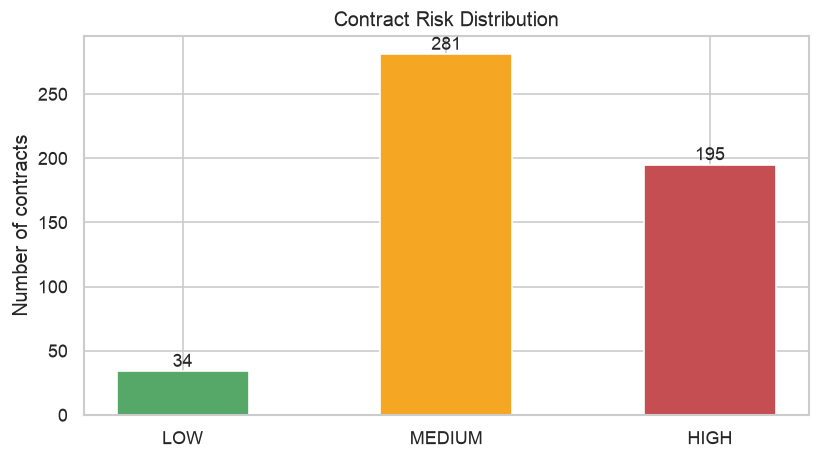

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
colors   = {"LOW": "#55A868", "MEDIUM": "#F5A623", "HIGH": "#C44E52"}
counts   = feature_df["risk_label"].value_counts().reindex(["LOW","MEDIUM","HIGH"])
bars     = ax.bar(counts.index, counts.values,
                  color=[colors[k] for k in counts.index], width=0.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontsize=11)

ax.set_ylabel("Number of contracts")
ax.set_title("Contract Risk Distribution")
plt.tight_layout()
plt.show()


## Train XGBoost Risk Classifier

We train on the **train split** contracts and evaluate on the **test split**.
This mirrors the same contract-level train/test partition used in the CUAD dataset.


In [6]:
train_feat = feature_df[feature_df["split"] == "train"]
test_feat  = feature_df[feature_df["split"] == "test"]

X_train = train_feat[FEATURE_COLS].values
y_train = train_feat["risk_level"].values
X_test  = test_feat[FEATURE_COLS].values
y_test  = test_feat["risk_level"].values

print(f"Train contracts : {len(X_train)}")
print(f"Test  contracts : {len(X_test)}")
LABEL_NAMES = {0: "LOW", 1: "MEDIUM", 2: "HIGH"}
print("Label distribution (train):")
for lbl, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f"  {LABEL_NAMES[lbl]} ({lbl}): {cnt}")
print("Label distribution (test):")
for lbl, cnt in zip(*np.unique(y_test, return_counts=True)):
    print(f"  {LABEL_NAMES[lbl]} ({lbl}): {cnt}")


Train contracts : 408
Test  contracts : 102
Label distribution (train):
  LOW (0): 31
  MEDIUM (1): 237
  HIGH (2): 140
Label distribution (test):
  LOW (0): 3
  MEDIUM (1): 44
  HIGH (2): 55


In [7]:
from sklearn.utils.class_weight import compute_sample_weight

# Handle potential class imbalance with balanced sample weights
sample_weights = compute_sample_weight("balanced", y_train)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0,
)

xgb.fit(X_train, y_train, sample_weight=sample_weights)
print("XGBoost training complete.")


XGBoost training complete.


## Evaluation

In [8]:
y_pred  = xgb.predict(X_test)
label_names = ["LOW", "MEDIUM", "HIGH"]

print("Classification Report (test set):")
print(classification_report(y_test, y_pred, target_names=label_names))


Classification Report (test set):
              precision    recall  f1-score   support

         LOW       1.00      1.00      1.00         3
      MEDIUM       0.98      1.00      0.99        44
        HIGH       1.00      0.98      0.99        55

    accuracy                           0.99       102
   macro avg       0.99      0.99      0.99       102
weighted avg       0.99      0.99      0.99       102



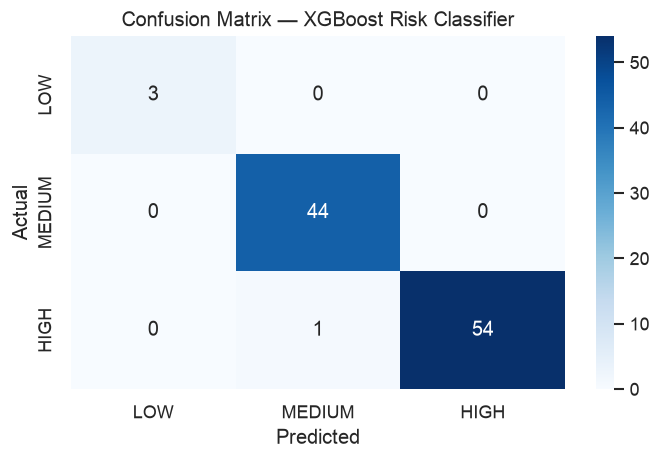

In [9]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — XGBoost Risk Classifier")
plt.tight_layout()
plt.show()


## SHAP Feature Importance

SHAP (SHapley Additive exPlanations) shows which clause categories drive the
risk score, and in which direction.  This is critical for LeaseIQ because it
gives lawyers an interpretable, clause-level explanation of why a contract
was flagged as HIGH risk.


In [10]:
explainer   = shap.TreeExplainer(xgb)
shap_raw    = explainer.shap_values(X_test)

# Handle both output formats across shap / xgboost versions:
#   list format  → list[n_classes] of (n_samples, n_features) arrays
#   3D format    → (n_samples, n_features, n_classes) numpy array
sv = np.array(shap_raw)
if sv.ndim == 3 and sv.shape[0] == 3:
    # Converted from list: shape (n_classes, n_samples, n_features)
    shap_high = sv[2]           # HIGH risk class
elif sv.ndim == 3 and sv.shape[-1] == 3:
    # Native 3D: shape (n_samples, n_features, n_classes)
    shap_high = sv[:, :, 2]    # HIGH risk class
else:
    shap_high = sv              # binary or unexpected format

print(f"Raw SHAP array shape : {sv.shape}")
print(f"shap_high shape      : {shap_high.shape}  (should be n_samples x n_features)")
print(f"Feature count        : {len(FEATURE_COLS)}")


Raw SHAP array shape : (102, 41, 3)
shap_high shape      : (102, 41)  (should be n_samples x n_features)
Feature count        : 41


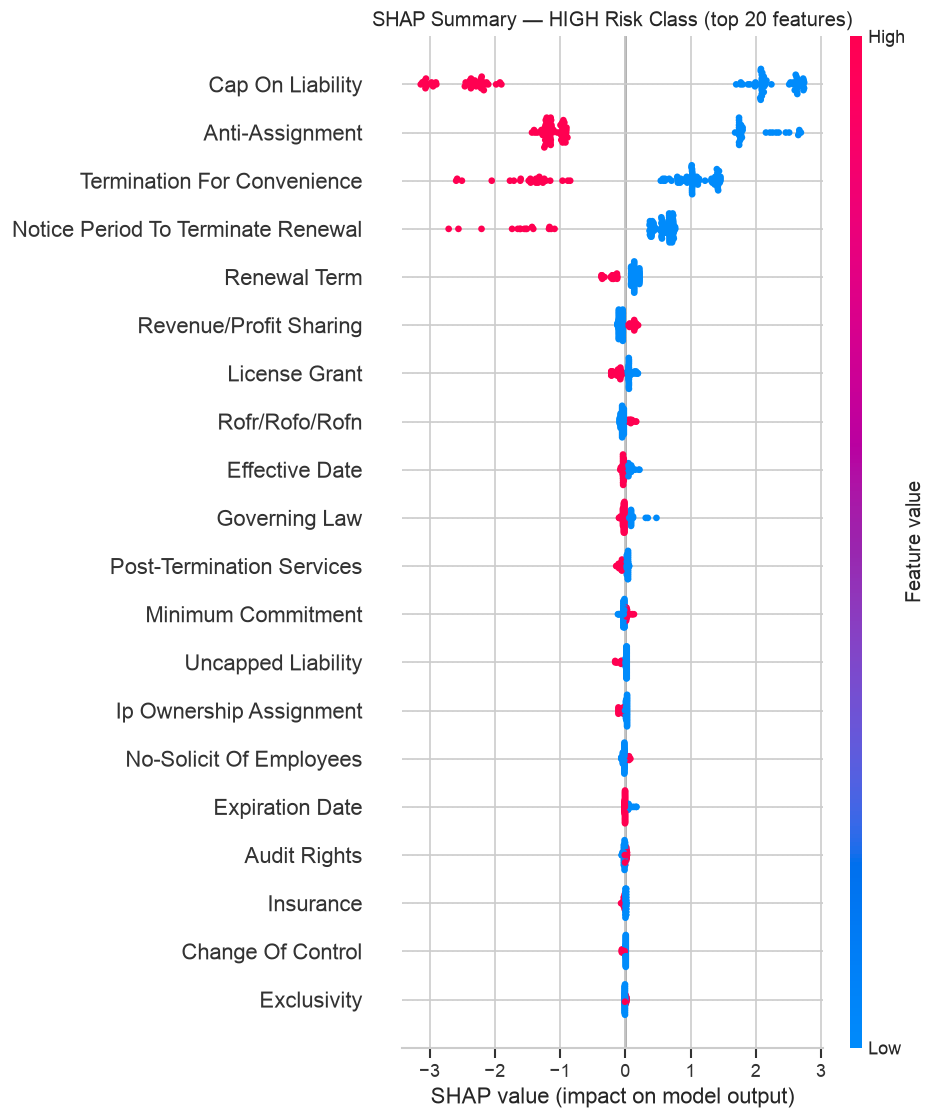

In [11]:
# Summary plot: impact of each feature on HIGH risk predictions
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_high, X_test,
    feature_names=FEATURE_COLS,
    plot_type="dot",
    max_display=20,
    show=False,
)
plt.title("SHAP Summary — HIGH Risk Class (top 20 features)")
plt.tight_layout()
plt.show()


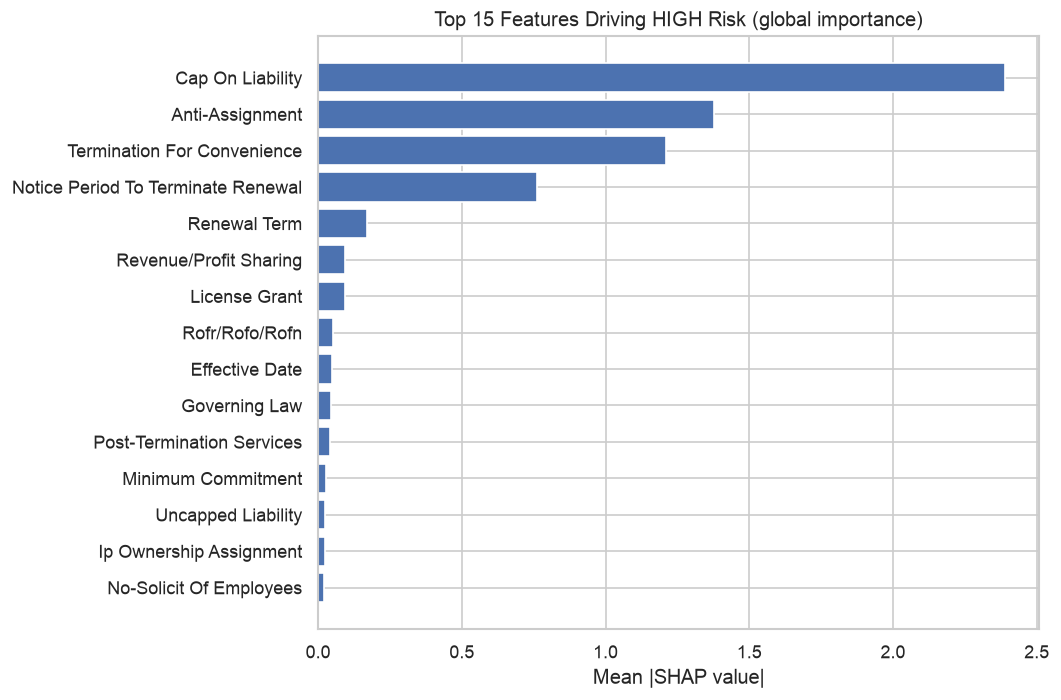

In [12]:
# Bar chart: mean absolute SHAP value per feature (global importance)
mean_abs_shap = np.abs(shap_high).mean(axis=0)
shap_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(shap_df["feature"][::-1], shap_df["mean_abs_shap"][::-1], color="#4C72B0")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 15 Features Driving HIGH Risk (global importance)")
plt.tight_layout()
plt.show()


## Sample Risk Reports

Generating a plain-English risk report for 3 test contracts to simulate the
LeaseIQ product output that a lawyer or paralegal would receive.


In [13]:
def format_risk_report(contract_id, row, xgb_model, feature_cols):
    x    = row[feature_cols].values.reshape(1, -1)
    pred = xgb_model.predict(x)[0]
    prob = xgb_model.predict_proba(x)[0]
    lmap = {0: "LOW", 1: "MEDIUM", 2: "HIGH"}

    present  = sorted([c for c in HIGH_RISK_CLAUSES if row.get(c, 0) == 1])
    missing  = sorted([c for c in HIGH_RISK_CLAUSES if row.get(c, 0) == 0])

    lines = [
        f"CONTRACT: {contract_id}",
        f"RISK TIER: {lmap[pred]}  "
        f"(P(LOW)={prob[0]:.0%}, P(MEDIUM)={prob[1]:.0%}, P(HIGH)={prob[2]:.0%})",
        "",
        "High-risk clauses PRESENT  : " + (", ".join(present) or "none"),
        "High-risk clauses MISSING  : " + (", ".join(missing) or "none"),
    ]
    return "\n".join(lines)

# Pick 3 contracts — one from each risk tier if possible
sample_rows = []
for level in [2, 1, 0]:
    subset = test_feat[test_feat["risk_level"] == level]
    if len(subset):
        sample_rows.append(subset.iloc[0])

for row in sample_rows:
    print("=" * 60)
    print(format_risk_report(row["contract_id"], row, xgb, FEATURE_COLS))
    print()


CONTRACT: ACCELERATEDTECHNOLOGIESHOLDINGCORP_04_24_2003-EX-10.13-JOINT VENTURE AGREEMENT
RISK TIER: HIGH  (P(LOW)=0%, P(MEDIUM)=1%, P(HIGH)=99%)

High-risk clauses PRESENT  : Anti-Assignment, Governing Law
High-risk clauses MISSING  : Cap On Liability, Notice Period To Terminate Renewal, Termination For Convenience

CONTRACT: AFSALABANCORPINC_08_01_1996-EX-1.1-AGENCY AGREEMENT
RISK TIER: MEDIUM  (P(LOW)=1%, P(MEDIUM)=87%, P(HIGH)=13%)

High-risk clauses PRESENT  : Cap On Liability, Governing Law, Termination For Convenience
High-risk clauses MISSING  : Anti-Assignment, Notice Period To Terminate Renewal

CONTRACT: ICORECONNECTINC_10_13_2010-EX-7.1-Strategic Alliance Agreement
RISK TIER: LOW  (P(LOW)=81%, P(MEDIUM)=19%, P(HIGH)=0%)

High-risk clauses PRESENT  : Anti-Assignment, Cap On Liability, Governing Law, Notice Period To Terminate Renewal, Termination For Convenience
High-risk clauses MISSING  : none



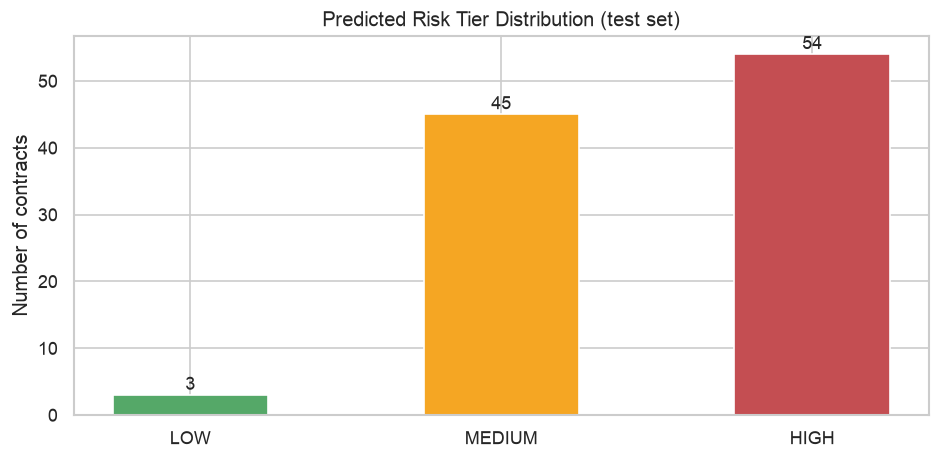

In [14]:
# Risk score distribution on test set
fig, ax = plt.subplots(figsize=(8, 4))
pred_labels = pd.Series(xgb.predict(X_test)).map({0:"LOW",1:"MEDIUM",2:"HIGH"})
counts      = pred_labels.value_counts().reindex(["LOW","MEDIUM","HIGH"], fill_value=0)
colors      = {"LOW":"#55A868","MEDIUM":"#F5A623","HIGH":"#C44E52"}
bars = ax.bar(counts.index, counts.values,
              color=[colors[k] for k in counts.index], width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(val), ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Number of contracts")
ax.set_title("Predicted Risk Tier Distribution (test set)")
plt.tight_layout()
plt.show()


## Summary

The XGBoost risk classifier provides:

1. **Interpretable risk tiers** (LOW / MEDIUM / HIGH) based on which critical
   clauses are present or absent.
2. **Probability scores** per tier, enabling thresholding for downstream actions.
3. **SHAP explanations** that pinpoint exactly which clause absence drives the
   risk score — giving lawyers a clear, clause-level justification.

In the full LeaseIQ pipeline, the binary feature vector fed to XGBoost would come
from LegalBERT's extraction predictions rather than ground-truth labels, completing
the end-to-end flow from raw contract text to risk report.
